# Title

### Imports and Notebook Settings


In [103]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [104]:
import os 
import re
from pathlib import Path

In [105]:
import pandas as pd
import numpy as np 

import matplotlib.pyplot as plt
# import seaborn as sns 
import plotly.express as px
import pprint 

In [106]:
ROOT = Path.cwd().parent

In [107]:
style_path = ( ROOT 
              / 'notebooks' 
              / 'styler.mplstyle'
              )
plt.style.use(style_path)

## GDELT Articles

### Records

In [108]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=gdelt"
    / "records.parquet"
)

df = pd.read_parquet(data_path)

In [109]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw'],
      dtype='object')

In [110]:
df.head()

,record_id,source,source_type,title,text,published_at,retrieved_at,url,region,categories,metadata,raw
0,20241101011500-1299,gdelt,api,Wall St ends lower as megacaps highlight AI costs,,2024-11-01T01:15:00+00:00,2026-06-22T16:31:13.894143+00:00,https://www.thestar.com.my/business/2024/11/01...,None,"[ECON_STOCKMARKET, TAX_ECON_PRICE, USPEC_POLIC...","{'source_common_name': 'thestar.com.my', 'gdel...","{'GKGRECORDID': '20241101011500-1299', 'DATE':..."
1,20241101013000-868,gdelt,api,Alliant Energy (NASDAQ:LNT) Releases FY25 Earn...,,2024-11-01T01:30:00+00:00,2026-06-22T16:31:13.894257+00:00,https://www.wkrb13.com/2024/11/01/alliant-ener...,US-US,"[ECON_STOCKMARKET, WB_698_TRADE, TAX_ECON_PRIC...","{'source_common_name': 'wkrb13.com', 'gdelt_ti...","{'GKGRECORDID': '20241101013000-868', 'DATE': ..."
2,20241101013000-1401,gdelt,api,Alliant Energy (NASDAQ:LNT) Updates FY24 Earni...,,2024-11-01T01:30:00+00:00,2026-06-22T16:31:13.894315+00:00,https://www.modernreaders.com/news/2024/11/01/...,US-US,"[ECON_STOCKMARKET, TAX_FNCACT, TAX_FNCACT_ANAL...","{'source_common_name': 'modernreaders.com', 'g...","{'GKGRECORDID': '20241101013000-1401', 'DATE':..."
3,20241101013000-1407,gdelt,api,Entergy to Pay SERC $141K for Standard Violations,,2024-11-01T01:30:00+00:00,2026-06-22T16:31:13.894446+00:00,https://www.rtoinsider.com/90891-entergy-pay-s...,US-USLA,"[WB_2024_ANTI_CORRUPTION_AUTHORITIES, WB_696_P...","{'source_common_name': 'rtoinsider.com', 'gdel...","{'GKGRECORDID': '20241101013000-1407', 'DATE':..."
4,20241101013000-327,gdelt,api,Xcel Welcomes Load Growth from Data Centers,,2024-11-01T01:30:00+00:00,2026-06-22T16:31:13.894201+00:00,https://www.rtoinsider.com/90904-xcel-welcomes...,None,[nan],"{'source_common_name': 'rtoinsider.com', 'gdel...","{'GKGRECORDID': '20241101013000-327', 'DATE': ..."


In [111]:
len(df)

29840

In [112]:
df["url"].isna().mean()

np.float64(0.0)

In [113]:
dup_rate = df["url"].duplicated().mean()
print(f"{dup_rate:.2%}")

0.00%


In [114]:
from urllib.parse import urlparse

df["domain"] = df["url"].apply(
    lambda x: urlparse(x).netloc
)

df["domain"].value_counts().head(30)

domain
www.yahoo.com                   1511
www.themarketsdaily.com          846
www.dailypolitical.com           778
www.tickerreport.com             653
finance.yahoo.com                463
www.marketscreener.com           460
www.prnewswire.com               338
www.modernreaders.com            333
theenterpriseleader.com          332
www.nola.com                     247
www.wkrb13.com                   243
www.mlive.com                    232
www.fool.com                     228
markets.financialcontent.com     211
www.utilitydive.com              209
www.insidermonkey.com            177
wwmt.com                         167
www.wnem.com                     166
www.wwltv.com                    155
www.theadvocate.com              155
www.wsoctv.com                   153
www.denverpost.com               148
www.wzzm13.com                   143
www.renewableenergyworld.com     142
www.wbrz.com                     139
www.finanznachrichten.de         138
www.wfae.org                   

In [115]:
df["title"].ne('').mean()

np.float64(0.9994973190348525)

In [116]:
df["title_length"] = (
    df["title"]
    .fillna("")
    .str.len()
)

df["title_length"].describe()

count    29840.000000
mean        72.699296
std         21.722478
min          0.000000
25%         59.000000
50%         71.000000
75%         84.000000
max        316.000000
Name: title_length, dtype: float64

In [117]:
from collections import Counter
import re

words = []

for title in df["title"].dropna():
    words.extend(
        re.findall(r"\b[a-z]+\b", title.lower())
    )

Counter(words).most_common(50)

[('to', 9117),
 ('energy', 8652),
 ('in', 7889),
 ('power', 6003),
 ('for', 4942),
 ('the', 4602),
 ('of', 4533),
 ('s', 4070),
 ('and', 3270),
 ('duke', 2888),
 ('on', 2245),
 ('a', 1880),
 ('as', 1829),
 ('new', 1782),
 ('xcel', 1678),
 ('nyse', 1677),
 ('data', 1658),
 ('company', 1560),
 ('storm', 1421),
 ('news', 1420),
 ('entergy', 1373),
 ('by', 1371),
 ('with', 1289),
 ('after', 1277),
 ('southern', 1273),
 ('center', 1258),
 ('shares', 1254),
 ('inc', 1248),
 ('customers', 1216),
 ('at', 1192),
 ('county', 1182),
 ('from', 1168),
 ('gas', 1163),
 ('winter', 1095),
 ('michigan', 1080),
 ('electric', 1075),
 ('llc', 1044),
 ('plant', 1036),
 ('outages', 1019),
 ('consumers', 999),
 ('is', 964),
 ('stock', 910),
 ('over', 906),
 ('so', 900),
 ('colorado', 890),
 ('coal', 887),
 ('utility', 885),
 ('centerpoint', 855),
 ('ai', 847),
 ('rate', 830)]

In [118]:
df.iloc[0]["categories"]

array(['ECON_STOCKMARKET', 'TAX_ECON_PRICE', 'USPEC_POLICY1',
       'TAX_FNCACT', 'TAX_FNCACT_CHIEF', 'TAX_MILITARY_TITLE',
       'TAX_MILITARY_TITLE_OFFICER', 'TAX_FNCACT_OFFICER',
       'UNGP_FORESTS_RIVERS_OCEANS', 'EPU_ECONOMY_HISTORIC', 'EPU_POLICY',
       'EPU_POLICY_FEDERAL_RESERVE', 'EPU_CATS_MONETARY_POLICY',
       'ECON_INFLATION', 'WB_1104_MACROECONOMIC_VULNERABILITY_AND_DEBT',
       'WB_442_INFLATION', 'TAX_FNCACT_ECONOMIST', 'EPU_POLICY_SPENDING',
       'TAX_FNCACT_TRADERS', 'WB_508_POWER_SYSTEMS',
       'WB_507_ENERGY_AND_EXTRACTIVES', 'EPU_CATS_MIGRATION_FEAR_FEAR',
       'WB_1150_VOLATILITY', 'ELECTION',
       'WB_1458_HEALTH_PROMOTION_AND_DISEASE_PREVENTION',
       'WB_635_PUBLIC_HEALTH', 'WB_1464_HEALTH_OF_THE_DISABLED',
       'WB_621_HEALTH_NUTRITION_AND_POPULATION'], dtype=object)

In [119]:
df.iloc[0]["metadata"]

{'source_common_name': 'thestar.com.my',
 'gdelt_timestamp': '20241101011500',
 'organizations': array(['microsoft', 'entergy', 'intel', 'federal reserve', 'nvidia',
        'family office', 'nasdaq', 'conocophillips', 'reuters'],
       dtype=object),
 'persons': array(['carol schleif', 'estee lauder'], dtype=object),
 'locations': array([], dtype=object),
 'tone': '-1.63043478260869,2.35507246376812,3.98550724637681,6.34057971014493,20.1086956521739,0.905797101449275,471',
 'theme_match': False,
 'organization_match': True,
 'location_match': False,
 'filter_match_count': None}

In [120]:
sample = df.sample(
    100,
    random_state=42
)

In [121]:
sample[
    ["title", "url"]
].to_csv(
    "gdelt_review.csv",
    index=False
)

In [122]:
daily_counts = (
    df.groupby(
        pd.to_datetime(df["published_at"]).dt.date
    )
    .size()
)

Text(0, 0.5, 'Article Counts')

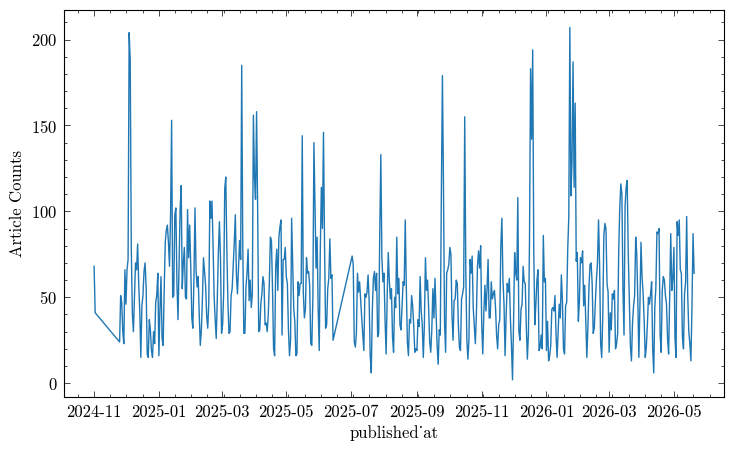

In [123]:
plt.figure(figsize=(8, 5))
daily_counts.plot()

plt.ylabel('Article Counts')

In [124]:
from collections import Counter
import json

org_counter = Counter()

for metadata in df["metadata"].dropna():
    try:
        data = json.loads(metadata) if isinstance(metadata, str) else metadata

        organizations = data.get("organizations", [])

        if organizations:
            org_counter.update(organizations)

    except Exception:
        continue

top_orgs = (
    pd.DataFrame(
        org_counter.most_common(50),
        columns=["organization", "count"]
    )
)

print(top_orgs)

               organization  count
0               duke energy    971
1          consumers energy    730
2                   entergy    624
3               xcel energy    589
4        centerpoint energy    281
5            alliant energy    115
6   american electric power     90
7          southern company     53
8        great river energy     14
9                dte energy     12
10          dairyland power      5


### Scraped Articles

In [167]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=gdelt"
    / "articles.parquet"
)

df = pd.read_parquet(data_path)

In [168]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw',
       'success', 'scrape_status', 'status_code', 'error_type',
       'error_message', 'fetch_method', 'fallback_used', 'extractor', 'author',
       'date', 'text_length', 'attempt_count'],
      dtype='object')

In [169]:
df['published_at'].min()

'2024-12-01T00:00:00+00:00'

In [170]:
df['published_at'].max()

'2026-05-20T22:30:00+00:00'

In [127]:
(
    df["success"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

success
True     66.46
False    33.54
Name: proportion, dtype: float64

In [128]:
(
    (df["scrape_status"].value_counts() / len(df))
    .mul(100)
    .round(2)
)

scrape_status
success             66.46
not_found           11.46
playwright_error     7.28
rate_limited         5.14
unknown              3.92
server_error         3.22
client_error         1.57
connection_error     0.43
parse_failed         0.36
http_error           0.16
Name: count, dtype: float64

In [129]:
(
    df.groupby("error_type")
      .size()
      .sort_values(ascending=False)
)

error_type
not_found           3381
playwright_error    2146
rate_limited        1517
unknown             1155
server_error         950
client_error         463
connection_error     126
parse_failed         107
http_error            46
dtype: int64

In [130]:
(
    df.groupby("status_code")
      .size()
      .sort_values(ascending=False)
)

status_code
200.0    19654
404.0     3381
429.0     1517
526.0      861
500.0       76
307.0       29
410.0       24
202.0       23
406.0       22
502.0        8
503.0        5
dtype: int64

In [131]:
df["text_length"].describe()

count    29490.000000
mean      2490.842455
std       2645.339735
min          0.000000
25%          0.000000
50%       1709.500000
75%       4379.000000
max       8000.000000
Name: text_length, dtype: float64

In [132]:
from urllib.parse import urlparse

df["domain"] = (
    df["url"]
    .apply(lambda x: urlparse(x).netloc)
)

In [133]:
(
    df.groupby("domain")["success"]
      .mean()
      .sort_values()
)

domain
newschannel20.com         0.0
www.khou.com              0.0
www.kgw.com               0.0
www.kens5.com             0.0
www.kdrv.com              0.0
                         ... 
790waeb.iheart.com        1.0
800wvhu.iheart.com        1.0
925maxima.com             1.0
1025kiss.com              1.0
1019bigwaax.iheart.com    1.0
Name: success, Length: 2468, dtype: float64

In [134]:
(
    df.groupby("domain")
      .size()
      .sort_values(ascending=False)
      .head(30)
)

domain
www.yahoo.com                   1483
www.themarketsdaily.com          822
www.dailypolitical.com           778
www.tickerreport.com             651
finance.yahoo.com                462
www.marketscreener.com           455
www.prnewswire.com               335
theenterpriseleader.com          321
www.modernreaders.com            312
www.nola.com                     243
www.mlive.com                    232
www.wkrb13.com                   228
www.fool.com                     226
markets.financialcontent.com     211
www.utilitydive.com              205
www.insidermonkey.com            176
wwmt.com                         167
www.wnem.com                     166
www.theadvocate.com              155
www.wwltv.com                    154
www.wsoctv.com                   153
www.denverpost.com               147
www.wzzm13.com                   143
www.renewableenergyworld.com     142
www.wbrz.com                     139
www.finanznachrichten.de         136
www.wfae.org                   

In [135]:
sample = (
    df[df["success"]]
    .sample(50, random_state=42)
)

In [136]:
sample['text']

15219    PINE ISLAND, Minn. — Google is building a 250,...
9929     MURPHY Thankful for a free dinner The free com...
22427    Dive Brief: - Overall U.S. generation M&A held...
16063    U.S. Sen. Jon Husted testifies remotely in ex-...
15412    President Trump highlighted the 2025 murder of...
19035    Urgency grows for home energy bill relief in M...
17199    Consumers Energy Customers Face Higher Bills W...
17286    Xcel Energy sending refunds to customers thank...
20947    Garbage can fire damages Fond du Lac house Pub...
22582    Life-Saving Winter Alert in Minnesota: What Yo...
20111    The small town of Carrboro, North Carolina is ...
24456    A sudden surge in tree planting across New Orl...
332      Severe Weather Forces Closures in Lake Charles...
22393    Southern US thaws from storm, but black ice ri...
12632    Meeting on Google’s planned Little Rock data c...
17509    LANSING, Mich. (WJRT) - Consumers Energy kicke...
2480     Funding available through Foundation for Appal.

## IEM AFOS

In [137]:
data_path = (
    ROOT
    / "data"
    / "silver"
    / "source=iem_afos"
    / "records.parquet"
)

df = pd.read_parquet(data_path)

In [139]:
df.columns

Index(['record_id', 'source', 'source_type', 'title', 'text', 'published_at',
       'retrieved_at', 'url', 'region', 'categories', 'metadata', 'raw'],
      dtype='object')

In [143]:
df.iloc[0]

record_id       4b8ac526c396cf72436a0d18c06354726d8985c8ec407e...
source                                                   iem_afos
source_type                                                   api
title           AFD | KIWX | Issued at 208 PM EST Sat Nov 30 2024
text            - Scattered lake effect snow showers over sout...
published_at                            2024-11-30T19:08:00+00:00
retrieved_at                     2026-06-22T16:31:05.531700+00:00
url             https://mesonet.agron.iastate.edu/cgi-bin/afos...
region                                                        IWX
categories                         [weather, nws, iem, afos, afd]
metadata        {'pil': 'AFDIWX', 'product_type': 'AFD', 'offi...
raw             564 \nFXUS63 KIWX 010522\nAFDIWX\n\nArea Forec...
Name: 0, dtype: object

In [144]:
df["metadata"].iloc[0]

{'pil': 'AFDIWX',
 'product_type': 'AFD',
 'office': 'KIWX',
 'sections': {'KEY MESSAGES': '- Scattered lake effect snow showers over southern Michigan will\n  become more numerous into Monday as they spread south into\n  northern Indiana.\n\n- Unseasonable cold continues through the week with highs\n  ranging from the upper 20s to low 30s with lows in the teens.',
  'DISCUSSION': 'Issued at 208 PM EST Sat Nov 30 2024\n\nPersisting neg height anomaly over ern Canada keeps an influx of \ncold, dry modified arctic air in place through the period. Bouts of \nlake effect, primarily confined to southern Michigan, are expected \nat times timed with generally weak disturbances embedded within \nsteep northwest flow aloft across the lakes/New England. \n\nWave disturbance over nrn BC this aftn will sharpen a bit as it \ndives sewd into the wrn OH valley by Mon. Somewhat better low level \nveering progged which will support a more robust but likely \nsmall/confined lake response within the ern 

In [140]:
df["source"].value_counts()

source
iem_afos    39294
Name: count, dtype: int64

In [145]:
df["product_type"] = df["metadata"].apply(
    lambda x: x.get("product_type")
)

df["product_type"].value_counts()

product_type
AFD    14487
LSR     9926
HWO     8312
SPS     3076
NPW     2485
WSW     1008
Name: count, dtype: int64

In [146]:
df["region"].value_counts()

region
LOT    5980
ILX    5960
IND    5955
DVN    5854
DMX    5427
IWX    5148
LSX    4970
Name: count, dtype: int64

In [148]:
(
    df.groupby(
        [
            pd.to_datetime(df["published_at"]).dt.date,
            "region"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

region,DMX,DVN,ILX,IND,IWX,LOT,LSX
published_at,,,,,,,
2024-11-30,1,2,0,0,1,1,1
2024-12-01,8,9,19,17,12,8,93
2024-12-02,33,34,15,12,25,8,26
2024-12-03,10,11,9,11,21,10,9
2024-12-04,16,19,10,16,11,15,10
...,...,...,...,...,...,...,...
2026-06-14,9,8,8,14,15,14,6
2026-06-15,8,7,8,12,9,12,7
2026-06-16,10,9,9,32,38,19,7


In [149]:
df["text_length"] = (
    df["text"]
    .fillna("")
    .str.len()
)

(
    df.groupby("product_type")["text_length"]
      .describe()
)

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
AFD,14487.0,971.859667,1101.790630,53.0,304.00,455.0,1347.0,8000.0
HWO,8312.0,1685.388114,792.896181,285.0,1197.75,1480.0,1945.0,8000.0
LSR,9926.0,589.275438,921.492570,330.0,368.00,397.0,447.0,8000.0
NPW,2485.0,1997.086117,1119.979527,321.0,1208.00,1750.0,2512.0,8000.0
SPS,3076.0,1302.420026,384.158267,477.0,1055.75,1258.0,1480.0,5783.0
WSW,1008.0,2525.853175,1519.523900,432.0,1340.00,2253.5,3325.0,8000.0


In [150]:
weather_terms = [
    "snow",
    "ice",
    "lake effect",
    "thunderstorm",
    "tornado",
    "wind",
    "heat",
    "cold",
    "rain",
    "flood"
]

for term in weather_terms:
    count = (
        df["text"]
        .str.lower()
        .str.contains(term, na=False)
        .sum()
    )

    print(term, count)

snow 9753
ice 26041
lake effect 977
thunderstorm 11023
tornado 2087
wind 16526
heat 3894
cold 7169
rain 14660
flood 3912


In [164]:
winter_terms = (
    df["text"]
    .str.lower()
    .str.contains(
        "snow|ice|blizzard|freezing",
        regex=True,
        na=False,
    )
)

summer_terms = (
    df["text"]
    .str.lower()
    .str.contains(
        "heat|thunderstorm",
        regex=True,
        na=False,
    )
)

In [165]:
monthly = (
    df.assign(
        winter=winter_terms,
        summer=summer_terms,
        month=pd.to_datetime(df["published_at"]).dt.month,
    )
    .groupby("month")[["winter", "summer"]]
    .sum()
)

print(monthly)

       winter  summer
month                
1        3875     340
2        3302     547
3        3719    1661
4        2866    1953
5        2265    1666
6        3622    2374
7        2017    1730
8        1302     981
9         722     725
10        785     394
11       1156     230
12       4336     340


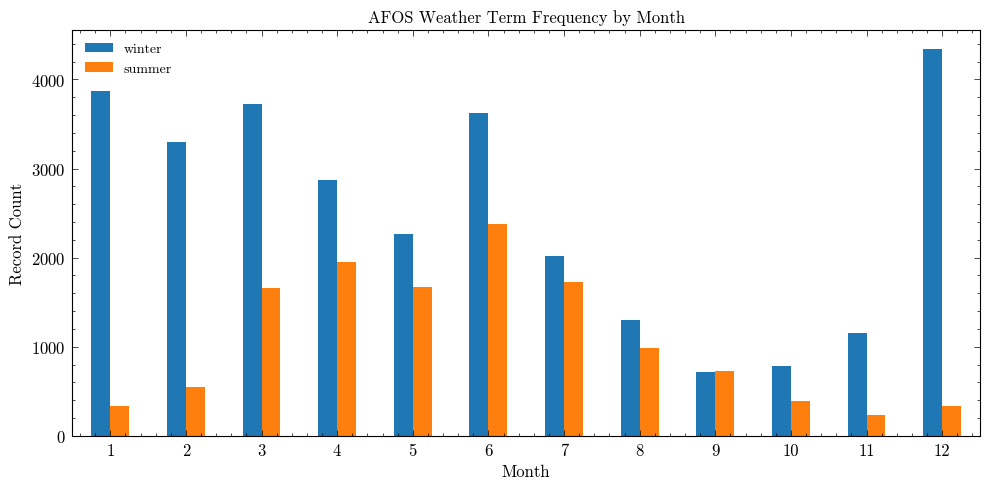

In [166]:
import matplotlib.pyplot as plt

monthly.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("AFOS Weather Term Frequency by Month")
plt.ylabel("Record Count")
plt.xlabel("Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()